In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Get_rmsd)=
# Get RMSD

*Calculating the root-mean-square deviation without prior spatial superposition.*

The function {func}`molsysmt.structure.get_rmsd` measures the root-mean-square deviation (RMSD) of atomic positions relative to a reference structure directly in the global coordinate frame without applying rigid-body translations or rotations.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.structure.get_rmsd`.
:::


## Basic usage

Let's show how to calculate the raw RMSD of backbone atoms over a pentalanine trajectory relative to the initial frame:


In [2]:
import molsysmt as msm
import matplotlib.pyplot as plt
import pyunitwizard as puw


In [3]:
molsys = msm.convert(msm.systems['pentalanine']['traj_pentalanine.h5msm'])


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


We compute the unaligned RMSD using {func}`molsysmt.structure.get_rmsd` with `reference_structure_index=0`:


In [4]:
rmsd_raw = msm.structure.get_rmsd(molsys, selection='backbone', reference_structure_index=0)


In [5]:
print('RMSD array shape:', rmsd_raw.shape)
print(f'RMSD at frame 0 (self-comparison): {rmsd_raw[0]:.4f}')
print(f'RMSD at frame 1: {rmsd_raw[1]:.4f}')


RMSD array shape: (5000,)
RMSD at frame 0 (self-comparison): 0.0000 nanometer
RMSD at frame 1: 0.4440 nanometer


## RMSD evolution across structural ensembles

We plot the unaligned RMSD over simulation time to observe positional drift:


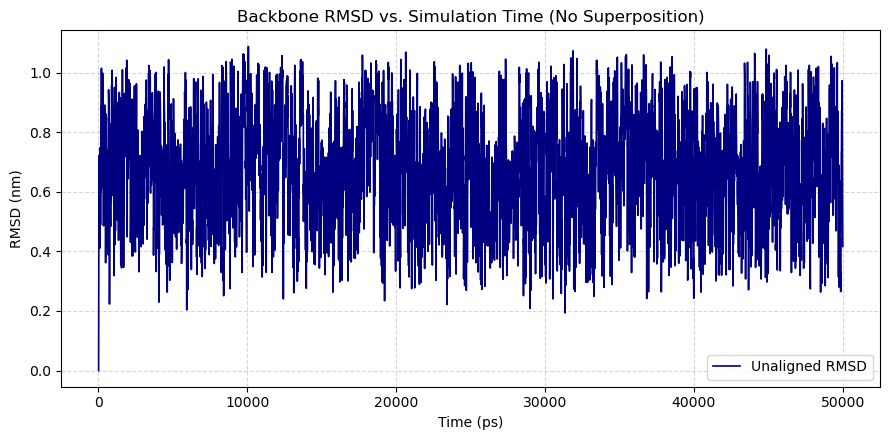

In [6]:
time = msm.get(molsys, element='system', time=True)
time_val = puw.get_value(time, to_unit='ps')
rmsd_val = puw.get_value(rmsd_raw, to_unit='nm')

plt.figure(figsize=(9, 4.5))
plt.plot(time_val, rmsd_val, color='navy', lw=1.2, label='Unaligned RMSD')
plt.xlabel('Time (ps)')
plt.ylabel('RMSD (nm)')
plt.title('Backbone RMSD vs. Simulation Time (No Superposition)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


## Comparing unaligned RMSD against optimal least-RMSD

While {func}`molsysmt.structure.get_rmsd` includes overall translation and rotation drift, {func}`molsysmt.structure.get_least_rmsd` superposes each structure onto the reference before calculating deviation, isolating pure internal conformational changes:


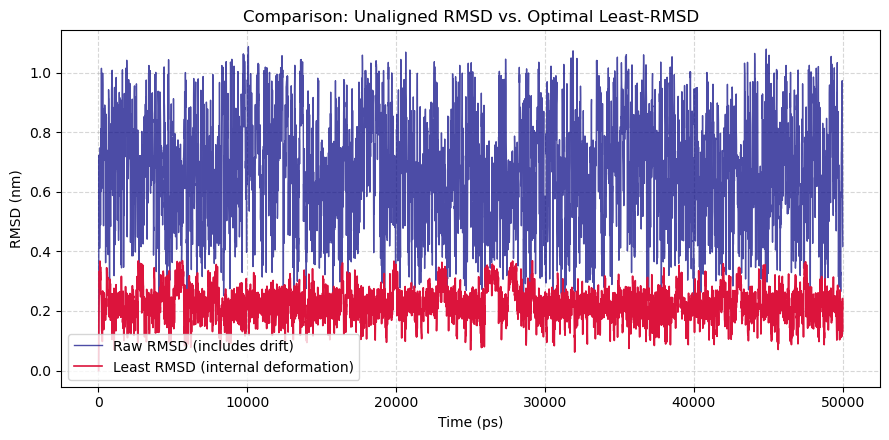

In [7]:
rmsd_least = msm.structure.get_least_rmsd(molsys, selection='backbone', reference_structure_index=0)
rmsd_least_val = puw.get_value(rmsd_least, to_unit='nm')

plt.figure(figsize=(9, 4.5))
plt.plot(time_val, rmsd_val, color='navy', lw=1.0, alpha=0.7, label='Raw RMSD (includes drift)')
plt.plot(time_val, rmsd_least_val, color='crimson', lw=1.2, label='Least RMSD (internal deformation)')
plt.xlabel('Time (ps)')
plt.ylabel('RMSD (nm)')
plt.title('Comparison: Unaligned RMSD vs. Optimal Least-RMSD')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems between different forms with {func}`molsysmt.basic.convert`.
- {ref}`Get <Tutorial_Get>`: Query system time and structural attributes with {func}`molsysmt.basic.get`.
- {ref}`Get least RMSD <Tutorial_Get_least_rmsd>`: Compute optimal Kabsch superposition RMSD with {func}`molsysmt.structure.get_least_rmsd`.
- {ref}`Least RMSD fit <Tutorial_Least_rmsd_fit>`: Superpose coordinates onto a reference structure with {func}`molsysmt.structure.least_rmsd_fit`.
- {ref}`Least RMSD align <Tutorial_Least_rmsd_align>`: Sequence-guided structural alignment for different topologies with {func}`molsysmt.structure.least_rmsd_align`.
:::
